In [2]:
import numpy as np
import matplotlib.pyplot as plt
from vectorHASH_cont import scaffold_layers, sensory_weights, relu
from scipy.integrate import solve_ivp

## Scaffold Only

In [ ]:
def gridtogrid(exc, inh, lambdas):
    """
    Makes the weight matrix for grid CAN dynamics with self excitation and lateral inhibition
    """
    # make sure lambdas is an np array
    lambdas = np.asarray(lambdas)
    Ng = np.sum(lambdas*lambdas)
    W_gg = np.zeros((Ng, Ng))
    i = 0

    for lam in lambdas:
        size = lam**2
        W_gg[i:i+size, i:i+size] = inh
        i += size

    np.fill_diagonal(W_gg, exc)
    return W_gg

def sigmoid(x, beta):
    return 1 / (1 + np.exp(-beta * x + 5))

def softmax(x, lambdas, beta=10):
    x1 = x.copy
    if x.ndim == 1:
        x1 = x[:, None]

    lambdas = np.asarray(lambdas)
    y = np.zeros_like(x1)
    i = 0
    for lam in lambdas:
        size = lam**2
        module = x1[i:i+size, :]
        exp = np.exp(beta * module)
        y[i:i+size, :] = exp / np.sum(exp, axis=0, keepdims=True)
        i += size

    if x.ndim == 1:
        return y[:, 0]
    return y

def glob_inh(x, lambdas, inh_stength):
    x1 = x.copy
    if x.ndim == 1:
        x1 = x[:, None]

    lambdas = np.asarray(lambdas)
    y = np.zeros_like(x1)
    i = 0
    for lam in lambdas:
        size = lam**2
        module = x1[i:i+size, :]
        sq_activity = module*module
        y[i:i+size, :] = sq_activity / (1 + inh_stength * np.sum(sq_activity, axis=0, keepdims=True))
        i += size

    if x.ndim == 1:
        return y[:, 0]
    return y


a = np.random.randn(4)
print(a, a.ndim)
b = softmax(a, [2])
print(b)
print(glob_inh(a, [2], 1))


In [31]:
lams = np.array([2,3])          # grid periods
Ng = np.sum(lams*lams)              # number of grid units
patts_total = np.prod(lams*lams)    # total number of patterns possible to store
Nh = 200                            # number of hc units
Ns = patts_total

W_gg = gridtogrid(1.2, -0.5, lams)
print(W_gg)
grid, W_hg, hc, W_gh = scaffold_layers(Ng, Nh, patts_total, lams, 0)
sens = np.sign(np.random.randn(Ns, patts_total))
W_hs, W_sh = sensory_weights(sens, hc)

# testing the weight matrix: grid state should stay at fixed point
g = grid[:, 12]
print("0 state:", np.argmax(g[:4]), np.argmax(g[4:]))

for i in range(3):
    g1 = sigmoid(W_gg @ g, 10)
    print(f"{i+1} state:", np.argmax(g1[:4]), np.argmax(g1[4:]))
print("\n")

for i in range(3):
    g2 = softmax(W_gg @ g, lams, 10)
    print(f"{i+1} state:", np.argmax(g2[:4]), np.argmax(g2[4:]))
print("\n")

for i in range(3):
    g3 = glob_inh(W_gg @ g, lams, 10)
    print(f"{i+1} state:", np.argmax(g3[:4]), np.argmax(g3[4:]))


[[ 1.2 -0.5 -0.5 -0.5  0.   0.   0.   0.   0.   0.   0.   0.   0. ]
 [-0.5  1.2 -0.5 -0.5  0.   0.   0.   0.   0.   0.   0.   0.   0. ]
 [-0.5 -0.5  1.2 -0.5  0.   0.   0.   0.   0.   0.   0.   0.   0. ]
 [-0.5 -0.5 -0.5  1.2  0.   0.   0.   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   1.2 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5]
 [ 0.   0.   0.   0.  -0.5  1.2 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5]
 [ 0.   0.   0.   0.  -0.5 -0.5  1.2 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5]
 [ 0.   0.   0.   0.  -0.5 -0.5 -0.5  1.2 -0.5 -0.5 -0.5 -0.5 -0.5]
 [ 0.   0.   0.   0.  -0.5 -0.5 -0.5 -0.5  1.2 -0.5 -0.5 -0.5 -0.5]
 [ 0.   0.   0.   0.  -0.5 -0.5 -0.5 -0.5 -0.5  1.2 -0.5 -0.5 -0.5]
 [ 0.   0.   0.   0.  -0.5 -0.5 -0.5 -0.5 -0.5 -0.5  1.2 -0.5 -0.5]
 [ 0.   0.   0.   0.  -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5  1.2 -0.5]
 [ 0.   0.   0.   0.  -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5  1.2]]
0 state: 0 3
1 state: 0 3
2 state: 0 3
3 state: 0 3


1 state: 0 3
2 state: 0 3
3 state: 0 3


1 state: 0 3
2 state

In [ ]:
def scaffold(t, state, Ng, Nh, W_gg, W_hg, W_gh, lambdas, b, tau_g, tau_h, beta=10):
    g = state[:Ng]
    h = state[Ng:]

    dg = (-g + softmax(W_gg @ g + 1*W_gh @ h, lambdas, beta)) / tau_g
    dh = (-h + relu(W_hg @ g - b)) / tau_h

    return np.concatenate([dg, dh])

# if intial state is a fixed point, should stay at that fixed point
patt = 0
#g0 = np.zeros(Ng)
g0 = grid[:, patt] 
h0 = hc[:, patt]
#h0 = np.zeros(Nh)
state0 = np.concatenate([g0, h0])

sol = solve_ivp(
    scaffold, t_span=(0, 50), y0=state0,
    args=(Ng, Nh, W_gg, W_hg, W_gh, lams, 0, 0.5, 1.0),
    method='RK45', t_eval=np.linspace(0, 50, 500)
)

g_traj = sol.y[:Ng, :]   # shape: (Ng, n_timepoints)
h_traj = sol.y[Ng:, :]

print(g_traj[:, -1],grid[:, patt])
print(np.allclose(g_traj[:, -1],grid[:,0]))
print(np.allclose(h0, h_traj[:, -1]))           # both may be false because allclose has more stringent tolerance values


[9.99998218e-01 5.95729349e-07 5.50065960e-07 6.36059887e-07
 9.99977471e-01 3.98043849e-06 2.29035483e-06 1.73389410e-06
 2.49984987e-06 3.08710803e-06 4.11293554e-06 2.08502577e-06
 2.73969974e-06] [1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
False
False


In [44]:
def get_overlap(state, pattern):
    """Returns overlap between two states, vectorized"""
    return np.mean(state * pattern, axis=0)

s_actual = np.sign(W_sh @ h0)
s_recalled = np.sign(W_sh @ h_traj[:, -1])
print(get_overlap(s_recalled, s_actual))   # if overlap is 1, then hc state was recovered correctly
print(np.allclose(s_recalled, s_actual)) 

0.0
False


In [93]:
def noisy_hc(hc, noise):
    """
    Adds gaussian (0,1) noise to hc state.
    noise: scaling parameter
    """
    
    noisy = hc + noise * np.random.randn(*hc.shape)
    return noisy

patt = 0
#g0 = grid[:, patt] 
g0 = np.zeros(Ng)
h0 = noisy_hc(hc[:, patt], 2.001)
state0 = np.concatenate([g0, h0])

sol = solve_ivp(
    scaffold, t_span=(0, 50), y0=state0,
    args=(Ng, Nh, W_gg, W_hg, W_gh, lams, 0, 0.5, 1.0),
    method='RK45', t_eval=np.linspace(0, 50, 500)
)

g_traj = sol.y[:Ng, :]   
h_traj = sol.y[Ng:, :]

print(g_traj[:, -1],grid[:, patt])
print(np.allclose(g_traj[:, -1],grid[:,0]))
print(np.allclose(h0, h_traj[:, -1]))

[ 9.99859442e-01  1.87625255e-48 -1.85378365e-47 -5.52015203e-51
  9.99859442e-01  1.13968824e-15  9.84976426e-21  7.35400278e-21
  1.05909461e-19  1.78098411e-17  1.17669390e-10  4.30714305e-20
  1.14909466e-18] [1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
False
False


In [81]:
s_actual = np.sign(W_sh @ h0)
s_recalled = np.sign(W_sh @ h_traj[:, -1])
print(get_overlap(s_recalled, sens[:,patt]))   # if overlap is 1, then hc state was recovered correctly
print(np.allclose(s_recalled, sens[:,patt])) 

-0.05555555555555555
False


In [104]:
def get_mutual_info(state, pattern):
    """Returns mutual information between two states, vectorized"""
    m = np.array(get_overlap(state, pattern))
    a, b = (1 + m)/2, (1 - m)/2
    s = a * np.log2(np.where(a > 0, a, 1)) + b* np.log2(np.where(b > 0, b, 1))
    return 1 + s

g0 = np.zeros(Ng)
mis = []
noise = np.linspace(0,2.5,100)
h0 = hc[:, 0]
s_actual = np.sign(W_sh @ h0)

for i in noise:
    mi_sum = 0
    for j in range(100):
        h0_noisy = noisy_hc(h0, i)
        state0 = np.concatenate([g0, h0_noisy])

        sol = solve_ivp(
            scaffold, t_span=(0, 50), y0=state0,
            args=(Ng, Nh, W_gg, W_hg, W_gh, lams, 0, 0.5, 1.0),
            method='RK45', t_eval=np.linspace(0, 50, 500)
        )

        h_traj = sol.y[Ng:, :]
        s_recalled = np.sign(W_sh @ h_traj[:, -1])
        mi_sum += get_mutual_info(s_recalled, sens[:, 0])
    mis.append(mi_sum / 10)

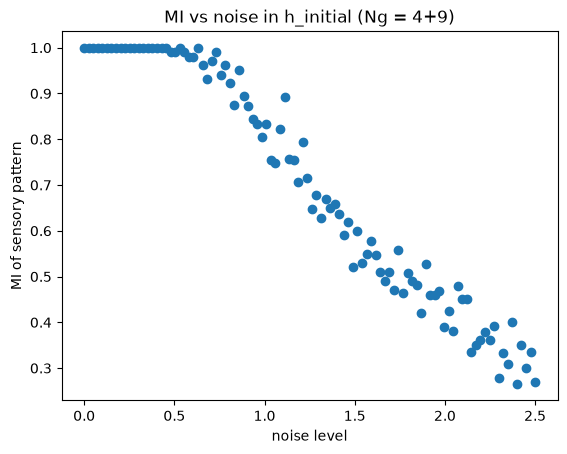

In [107]:
plt.scatter(noise, np.array(mis)/10)
plt.title("MI vs noise in h_initial (Ng = 4+9)")
plt.xlabel("noise level")
plt.ylabel("MI of sensory pattern")
plt.show()

In [39]:
def tanh(x, beta):
    return np.tanh(beta * x)

                   
def vectorhash(t, state, Ng, Nh, W_gg, W_hg, W_gh, W_hs, W_sh, lambdas, b, tau_g, tau_h, tau_s, beta=10):
    g = state[:Ng]
    h = state[Ng : Ng+Nh]
    s = state[Ng+Nh:]

    dg = (-g + softmax(W_gg @ g + 1*W_gh @ h, lambdas, beta)) / tau_g
    dh = (-h + relu(W_hg @ g + W_hs @ s - b)) / tau_h
    ds = (-s + tanh(W_sh @ h, beta)) / tau_s

    return np.concatenate([dg, dh, ds])

patt = 0
g0 = grid[:, patt]
h0 = hc[:, patt]
s0 = sens[:, patt]
state0 = np.concatenate([g0, h0, s0])

sol2 = solve_ivp(
    vectorhash, t_span=(0, 50), y0=state0,
    args=(Ng, Nh, W_gg, W_hg, W_gh, W_hs, W_sh, lams, 0, 0.5, 1.0, 1.0),
    method='RK45', t_eval=np.linspace(0, 50, 500)
)

g_traj2 = sol2.y[:Ng, :]   
h_traj2 = sol2.y[Ng:Ng+Nh, :]
s_traj2 = sol2.y[Ng+Nh:, :]

print(np.allclose(g_traj2[:, -1],grid[:,0]))
print(g_traj2[:, -1],grid[:,0])
print(np.allclose(h0, h_traj2[:, -1]))  
print(np.allclose(s_traj2[:, -1], s_actual)) 

False
[1.00000000e+00 8.47939323e-38 6.74954013e-43 6.25480921e-36
 1.00000000e+00 3.10224766e-07 1.04821389e-10 1.76862917e-13
 9.52037469e-10 2.22167465e-07 9.15411950e-07 1.93889070e-11
 6.10635149e-09] [1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
False
True
